# Validate a saved checkpoint on the validation set

This notebook loads a Lightning checkpoint, evaluates it on the validation dataset, and shows metrics + confusion matrix.

In [5]:
# If needed, uncomment and run once:
# %pip install scikit-learn seaborn

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

In [6]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root (pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    # Ensure Hydra targets like src.data... are importable in notebook kernels.
    sys.path.insert(0, str(PROJECT_ROOT))

CKPT_PATH = Path(r"C:\Users\lovro\Desktop\hackatoni\transformer_architecture\outputs\train\version_5\checkpoints\epochepoch=42-loss_valloss_val=0.0771.ckpt")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint exists: {CKPT_PATH.exists()}")
print(f"Device: {DEVICE}")

Project root: C:\Users\lovro\Desktop\hackatoni\transformer_architecture
Checkpoint exists: True
Device: cuda


In [7]:
# Compose the same Hydra config used in training
with initialize_config_dir(config_dir=str(PROJECT_ROOT / "configs"), version_base=None):
    cfg = compose(config_name="train.yaml")

datamodule = instantiate(cfg.data)
model = instantiate(cfg.model)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
missing, unexpected = model.load_state_dict(state_dict, strict=False)

model = model.to(DEVICE).eval()
datamodule.setup("fit")
val_loader = datamodule.val_dataloader()

print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")
if missing:
    print('First missing key:', missing[0])
if unexpected:
    print('First unexpected key:', unexpected[0])

Missing keys: 0
Unexpected keys: 0


In [8]:
all_preds = []
all_targets = []
all_losses = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = model.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)

        all_losses.append(loss.item())
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)
val_loss = float(np.mean(all_losses))

acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame([{
    "val_loss": val_loss,
    "accuracy": acc,
    "precision_macro": prec_macro,
    "recall_macro": rec_macro,
    "f1_macro": f1_macro,
    "precision_weighted": prec_w,
    "recall_weighted": rec_w,
    "f1_weighted": f1_w,
}])

metrics_df.round(5)

,val_loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.07115,0.95333,0.95107,0.95349,0.95058,0.95406,0.95333,0.95201


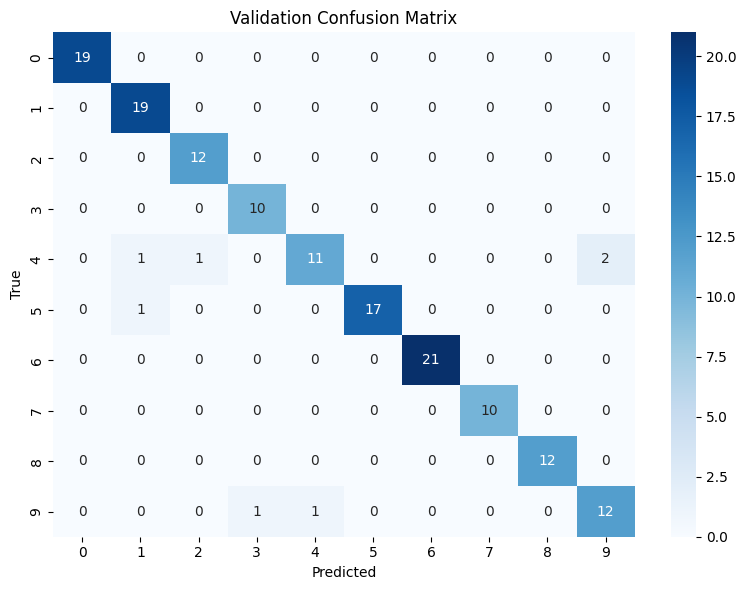

In [9]:
# Class labels for nicer plots/reports
class_to_idx = datamodule.valid_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
labels_sorted = [idx_to_class[i] for i in sorted(idx_to_class)]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels_sorted))))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [10]:
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(labels_sorted))),
    target_names=labels_sorted,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
report_df.round(5)

,precision,recall,f1-score,support
0,1.00000,1.00000,1.00000,19.00000
1,0.90476,1.00000,0.95000,19.00000
2,0.92308,1.00000,0.96000,12.00000
3,0.90909,1.00000,0.95238,10.00000
4,0.91667,0.73333,0.81481,15.00000
5,1.00000,0.94444,0.97143,18.00000
6,1.00000,1.00000,1.00000,21.00000
7,1.00000,1.00000,1.00000,10.00000
8,1.00000,1.00000,1.00000,12.00000
9,0.85714,0.85714,0.85714,14.00000
